# Structured approach to temporal queries on ohsome-planet file

> **Data used**: OpenStreetMap data for the Netherlands extracted from GeoFabrik and processed using the [ohsome-planet tool](https://github.com/GIScience/ohsome-planet) developed by HeiGit. <br>
> This notebook focuses on highlighting the challenges I came across while working with the ohsome-planet latest and history file

## Introduction

##### **Temporal Challenges - Repeating Analysis** 

- Temporal questions frequently require reapplying the same filtering and interval logic.

- **Issue:** manual queries are repetitive, error-prone, and inconsistent across users. Small details easily cause errors (inclusive/exclusive time boundaries; deleted and modified features)
- **Solution:** encode logic **once** by providing users with functions (similar to what is already done with the Ohsome API), making repeated temporal queries reliable **both for external users and/or the team**. 


##### **Linking Challenges - Join** 
- Some questions require linking members/refs information "across files":
    - latest --> latest
    - latest --> history
    - history --> history
- **Issue:** Joins often return inconsistent or incorrect results, especially when members are added, removed or moved over time
- **Solution:** Functions could ensure joins behave as expected.

## Setup

This section installs required libraries, imports them and sets up DuckDB with spatial extension

### Import libraries

In [1]:
from pathlib import Path
import duckdb
from lonboard import Map, viz, PathLayer
import calendar
from datetime import datetime
import ipywidgets as widgets
import pandas as pd
import matplotlib.pyplot as plt

### Load and install DuckDB spatial extension

In [2]:
duckdb.sql("INSTALL spatial; LOAD spatial;")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## Define path to ohsome-planet **history** parquet file

In [33]:
BASE_PATH = Path("/data/ohsome_planet/data/ohsome-planet") # add your own path to ohsome-planet folder
osm_history_path = BASE_PATH / "out-netherlands" / "contributions" / "history" / "*.parquet"

# AOI: Kapelle, Netherlands

In [34]:
# Filter OSM history data for the Netherlands and keep only data for the city of Kapelle
kapelle_osm_history = duckdb.sql(f"""
SELECT * REPLACE(ST_GeomFromWKB(geometry) as geometry)
FROM read_parquet('{osm_history_path}')
WHERE 1=1
AND bbox.xmin BETWEEN 3.943491 AND 3.981857  
AND bbox.xmax BETWEEN 3.943491 AND 3.981857
AND bbox.ymin BETWEEN 51.469764 AND 51.494673
AND bbox.ymax BETWEEN 51.469764 AND 51.494673
LIMIT 10
""")

kapelle_osm_history.show(max_width=100)
viz(kapelle_osm_history.filter("geometry IS NOT NULL"))

┌─────────┬──────────────────────┬───┬──────────────────────┬───────────┬────────────┐
│ status  │      valid_from      │ … │       members        │ countries │ build_time │
│ varchar │ timestamp with tim…  │   │ struct("type" varc…  │ varchar[] │   int64    │
├─────────┼──────────────────────┼───┼──────────────────────┼───────────┼────────────┤
│ history │ 2012-06-18 22:54:5…  │ … │ NULL                 │ []        │       1300 │
│ history │ 2014-05-06 16:28:0…  │ … │ NULL                 │ []        │       1600 │
│ history │ 2015-11-29 20:38:0…  │ … │ NULL                 │ []        │       1100 │
│ history │ 2017-02-01 20:28:0…  │ … │ NULL                 │ []        │        900 │
│ history │ 2017-05-13 20:59:0…  │ … │ NULL                 │ []        │       1000 │
│ history │ 2019-12-05 00:33:4…  │ … │ NULL                 │ []        │       1500 │
│ deleted │ 2021-10-06 16:27:5…  │ … │ NULL                 │ []        │       1600 │
│ history │ 2012-06-16 11:14:4…  │ … │ NULL

# Temporal challenges

## Activity vs State based perspective

|               | Activity-Based View               | State-Based View                               |
|---------------------|-------------------------------------------|-----------------------------------------------|
| What does one row represent?  | Each row is a unique edit/change event | Each row represents a time interval in which version was valid |
| Focus                | What changed and when?                     | What existed and when?                        |


**Activity-based perspective** (current schema serves this perspective the best) 

- One row represents one change event to an OSM object (this change can describe an episode of creation, modification (tag/geometry), deletion)
- If one building was edited 4 times, there will be 4 rows in the database 
- (e.g. group by month, between valid_from and valid_to etc.) --> naturally counts editing activity
    
**State-based perspective**

- One row represent one OSM version, containing information about for how long that version has been valid (i.e. visible on the OSM map)
- If one building has 4 versions, there will be 4 rows in the database (however, **it does not mean that it was valid for for years**)
- Challenge: how to deal with duplicate versions

**Time filtering with a state-based perspective in mind requires additional logic**

## Functions

### Internal helper functions

#### _check_validity_input_time_parameters(date)

In [12]:
# Check validity of time parameters
def _check_validity_input_time_parameters(date):
    """
    Read a date string against a list of accepted formats and returns the datetime object plus the matching format. 
    If none of the formats match, it raises an error. Later code will not run  

    Parameters:
    data (str): accepted formats are ['YYYY-MM-DD HH:MM:SS', 'YYYY-MM-DD',  'YYYY-MM', 'YYYY']

    Returns: 
    - dt (str): date object
    - fmt (str): time granularity of date object
    """

    formats = ['%Y-%m-%d %H:%M:%S', '%Y-%m-%d', '%Y-%m', '%Y']

    dt = None 
    for fmt in formats:
        try: 
            dt = datetime.strptime(date, fmt)
            return dt, fmt
        except ValueError: 
            continue
    
    if dt == None:
        raise ValueError(f"Invalid date format: '{date}'. Expected formats: YYYY, YYYY-MM, YYYY-MM-DD or YYYY-MM-DD HH:MM:SS")

#### _normalize_start(dt, fmt)

In [13]:
def _normalize_start(dt, fmt):
    """
    Infer user intent for start_of parameter based on granularity of date object. Arguments derived using _check_validity_input_time_parameters() helper function

    Parameters:
    - dt (str): date object
    - fmt (str): granularity of date object

    Returns: 
    - dt (str): Noramalized date object
    """
    # Assumes dt and fmt have already been validated by _check_validity_input_time_parameters
    if fmt == '%Y':
        return dt.replace(month=1, day=1, hour=0, minute=0, second=0)
    elif fmt == '%Y-%m':
        return dt.replace(day=1, hour=0, minute=0, second=0)
    elif fmt == '%Y-%m-%d':
        return dt.replace(hour=0, minute=0, second=0)
    else:  # '%Y-%m-%d %H:%M:%S'
        return dt

#### _normalize_end(dt, fmt)

In [14]:
def _normalize_end(dt, fmt):
    """
    Infer user intent for end_of parameter based on granularity of date object. Arguments derived using _check_validity_input_time_parameters() helper function

    Parameters:
    - dt (str): date object
    - fmt (str): granularity of date object

    Returns: 
    - dt (str): Noramalized date object
    """
    # Assumes dt and fmt have already been validated by _check_validity_input_time_parameters
    if fmt == '%Y':
        return dt.replace(month=12, day=31, hour=23, minute=59, second=59)
    elif fmt == '%Y-%m':
        last_day = calendar.monthrange(dt.year, dt.month)[1]
        return dt.replace(day=last_day, hour=23, minute=59, second=59)
    elif fmt == '%Y-%m-%d':
        return dt.replace(hour=23, minute=59, second=59)
    else:  # '%Y-%m-%d %H:%M:%S'
        return dt

### Main Functions

#### `get_snapshot()` function

In [15]:
def get_snapshot(osm_history_data, date, mode=None, where_clauses=None):
    """
    Retrieve OSM data at specific point in time (snapshot)
    
    Parameters:
        osm_history_data: parquet file path 
        date: snapshot date string
        mode: None, 'start_of', or 'end_of'
        where_clauses: list of additional SQL WHERE conditions

    Returns:
    snapshot_date (str): string specifying snapshot of OSM data 
    data (DuckDB PyRelation): OSM data as of snapshot_date 
    """
    
    # Validate and convert date string
    dt, input_granularity = _check_validity_input_time_parameters(date)

    if mode == 'start_of':
        dt = _normalize_start(dt, input_granularity)
    elif mode == 'end_of':
        dt = _normalize_end(dt, input_granularity)
    # Normalized already to start_of in _check_validity_input_time_parameters, unless precise input provided
    elif mode is None:
        dt = _normalize_start(dt, input_granularity)
    else:
        raise ValueError(f"Invalid mode. Expected None, 'start_of' or 'end_of', got '{mode}'")

    # Format datetime object to string for SQL
    snapshot_date = dt.strftime('%Y-%m-%d %H:%M:%S')

    # Dynamically build SQL based on custom WHERE filters
    if where_clauses is None:
        where_clauses = ''
    else: 
        where_clauses = "\n AND " + "\n AND ".join(where_clauses)
        
    query = f"""
        SELECT * REPLACE(ST_GeomFromWKB(geometry) as geometry)
        FROM read_parquet('{osm_history_data}')
        WHERE 1=1
        AND valid_from <= '{snapshot_date}'
        AND valid_to > '{snapshot_date}'
        AND status != 'deleted'
        {where_clauses}
        """
    
    print(f"Snapshot of OSM history data as of: {snapshot_date}")
    return snapshot_date, duckdb.sql(query)

- #### Test `get_snapshot()` function

In [16]:
test_cases = [
        # (date, mode, expected_behavior)
        ('2015', None, 'Should parse as 2015-01-01 00:00:00'),
        ('2015', 'start_of', 'Should accept (start of year)'),
        ('2015', 'end_of', 'Should normalize to 2015-12-31 23:59:59'),
        ('2015-02', 'end_of', 'Should handle February (28 days)'),
        ('2016-02', 'end_of', 'Should handle leap year February (29 days)'),
        ('2015-06-15 14:30:00', 'start_of', 'Should reject. Contradictory'),
        ('invalid', None, 'Should raise ValueError'), # error results signals function works as expected
    ]
    
for date, mode, expected in test_cases:
    try:
        dt, _ = get_snapshot('/local/data/vbo226/my_dataset/latest/*.parquet', date, mode)
        print(f"✓ {date} with mode={mode}: {dt}") # Input with mode resulted in dt
    except ValueError as e:
        print(f"✗ {date} with mode={mode}: {e}") # Input with mode resulted in error

Snapshot of OSM history data as of: 2015-01-01 00:00:00
✓ 2015 with mode=None: 2015-01-01 00:00:00
Snapshot of OSM history data as of: 2015-01-01 00:00:00
✓ 2015 with mode=start_of: 2015-01-01 00:00:00
Snapshot of OSM history data as of: 2015-12-31 23:59:59
✓ 2015 with mode=end_of: 2015-12-31 23:59:59
Snapshot of OSM history data as of: 2015-02-28 23:59:59
✓ 2015-02 with mode=end_of: 2015-02-28 23:59:59
Snapshot of OSM history data as of: 2016-02-29 23:59:59
✓ 2016-02 with mode=end_of: 2016-02-29 23:59:59
Snapshot of OSM history data as of: 2015-06-15 14:30:00
✓ 2015-06-15 14:30:00 with mode=start_of: 2015-06-15 14:30:00
✗ invalid with mode=None: Invalid date format: 'invalid'. Expected formats: YYYY, YYYY-MM, YYYY-MM-DD or YYYY-MM-DD HH:MM:SS


#### `get_snapshot_deleted()` function

This function is identical to get_snapshot(), with the only difference that it filters for **deleted features** instead of active features (status = 'deleted' vs status != 'deleted').

In [17]:
#Important to separate from get_snapshot (for active features)
def get_snapshot_deleted(osm_history_data, date, mode=None, where_clauses=None):
    dt, input_granularity = _check_validity_input_time_parameters(date)
    
    if mode == 'start_of':
        dt = _normalize_start(dt, input_granularity)
    elif mode == 'end_of':
        dt = _normalize_end(dt, input_granularity)
    elif mode is None:
        dt = _normalize_start(dt, input_granularity)
    
    snapshot_date = dt.strftime('%Y-%m-%d %H:%M:%S')

    if where_clauses is None:
        where_clauses = ''
    else:
        where_clauses = "\n AND " + "\n AND ".join(where_clauses)

    query = f"""
        SELECT * REPLACE(ST_GeomFromWKB(geometry) as geometry)
        FROM read_parquet('{osm_history_data}')
        WHERE 1=1
        AND valid_from = '{snapshot_date}' -- Exact match too restrictive probably (allow deletion during this day/period - confusion with get_period_deleted?)
        AND status = 'deleted'
        {where_clauses}
    """
    return snapshot_date, duckdb.sql(query)

#### `get_snapshot_summary()` function

In [18]:
def get_snapshot_summary(osm_history_data, date, group_by, metrics=['count'], mode=None, where_clauses=None):
    """
    Get aggregated statistics at a point in time (not individual features)
    
    Parameters:
        osm_history_data: parquet file path 
        date: snapshot date string
        group_by: column(s) to group by e.g. 'osm_type' or ['osm_type', 'status'] #support more complex filtering
        metrics: list of metrics to compute:
            - 'count': number of features
            - 'total_length': sum of lengths
            - 'total_area': sum of areas
            - 'avg_tags': average number of tags
        mode: None, 'start_of', or 'end_of'
        where_clauses: list of additional SQL WHERE conditions

    Returns:
    snapshot_date (str): string specifying snapshot of OSM data 
    data (DuckDB PyRelation): aggregate statistics derived from snapshot data 
    """
    
    # Validate and convert date string
    dt, input_granularity = _check_validity_input_time_parameters(date)
    if mode == 'start_of':
        dt = _normalize_start(dt, input_granularity)
    elif mode == 'end_of':
        dt = _normalize_end(dt, input_granularity)
    elif mode is None:
        dt = _normalize_start(dt, input_granularity)
    else:
        raise ValueError(f"Invalid mode. Expected None, 'start_of' or 'end_of', got '{mode}'")

    snapshot_date = dt.strftime('%Y-%m-%d %H:%M:%S')

    # Dynamically build group_by clause
    if isinstance(group_by, list):
        group_by_clause = ", ".join(group_by)
    else:
        group_by_clause = group_by

    # Dyncamically build metrics
    metric_clauses = []
    for metric in metrics:
        if metric == 'count':
            metric_clauses.append("COUNT(*) as count")
        elif metric == 'total_length':
            metric_clauses.append("SUM(ST_Length(geometry)) as total_length")
        elif metric == 'total_area':
            metric_clauses.append("SUM(ST_Area(geometry)) as total_area")
        elif metric == 'avg_tags':
            metric_clauses.append("AVG(cardinality(tags)) as avg_tags")
        else:
            raise ValueError(f"Unknown metric '{metric}'. Expected: count, total_length, total_area, avg_tags")
    
    select_metrics = ",\n ".join(metric_clauses)

    
    # Dynamically build SQL WHERE clauses 
    if where_clauses is None:
        where_clauses = ''
    else:
        where_clauses = "\n AND " + "\n AND ".join(where_clauses)
        
    query = f"""
        SELECT 
        {group_by_clause},
        {select_metrics}
        FROM read_parquet('{osm_history_data}')
        WHERE valid_from <= '{snapshot_date}'
        AND valid_to > '{snapshot_date}'
        AND status != 'deleted'
        {where_clauses}
        GROUP BY {group_by_clause}
        ORDER BY count DESC
    """

    print(f"Snapshot summary as of: {snapshot_date}")
    return snapshot_date, duckdb.sql(query)

#### `get_timeseries()` function

In [19]:
def get_timeseries(osm_history_data, dates, group_by, metrics=['count'], mode=None, where_clauses=None):
    """
    Get aggregated statistics across multiple points in time
    
    Parameters:
        osm_history_data: parquet file path or DuckDB table name
        dates: list of date strings e.g. ['2014', '2015', '2016']
        group_by: column(s) to group by e.g. 'osm_type'
        metrics: list of metrics to compute: 'count', 'total_length', 'total_area', 'avg_tags'
        mode: None, 'start_of', or 'end_of'
        where_clauses: list of additional SQL WHERE conditions

    Returns:
    snapshot_date (str): string specifying snapshot of OSM data 
    data (DuckDB PyRelation): aggregate statistics derived from multiple snapshots across time
    """
    results = []
    for date in dates:
        snapshot_date, summary = get_snapshot_summary(
            osm_history_data, date, 
            group_by=group_by,
            metrics=metrics,
            mode=mode,
            where_clauses=where_clauses
        )
        df = summary.df()
        df['snapshot_date'] = snapshot_date
        results.append(df)
    
    timeseries_df = pd.concat(results, ignore_index=True)
    return timeseries_df

#### `get_period_representative()` function

In [20]:
def get_period_representative(osm_data, strategy, start_period, end_period=None, where_clauses=None):
    """
    Retrieve one representative version of each feature within a time period. 

    This function selects a single "best" version for each feature that existed during the specified period, according to the chosen strategy.

    Parameters:
    - osm_data (str): path to ohsome history parquet file 
    - start_period (str): Start of period 
        - '2015' -> Full year 2015 (2015-01-01 to 2015-12-31)
        - '2015-06' -> Full month (2015-06-01 to 2015-06-30)
        - '2015-06-15' -> Full day (2015-06-15 00:00:00 to 23:59:59)
        - '2015-01-01' (with end period) -> custom start 

    - end_period (str, optional): End of custom period
        - if None -> Inferred from start_period granularity
        - if provided (with start period) -> explicit custom end 

    - strategy (str): How to select representative version 
        - 'longest': Version that existed the longest in period
                    -> Filters out vandalism, gets most stable state
        - 'latest': Most recent version in period 
                    -> Final state at the end of period
        - 'earliest':  First version in period 
                    -> Initial state at the start of period (i.e. oldest version)
        - 'all': All vesions within period (returns everything)
                    -> For detailed change analysis

        where_clauses: list of additional SQL WHERE conditions

    Returns: 
    - dt_str_start_period (str): string specifying the start date of period 
    - dt_str_start_period (str): string specifying the end date of period
    - data (Duckdb PyRelation): OSM data within start_date and end_date interval. Results will look differenlty depending on strategy chosen
    """

    # Validate start_period up front, regardless of whether end_period is provided
    dt_start_period, fmt_start_period = _check_validity_input_time_parameters(start_period)
    
    if end_period is None:
        # Infer end date if only start_period provided
        dt_start_period = _normalize_start(dt_start_period, fmt_start_period)
        dt_end_period = _normalize_end(dt_start_period, fmt_start_period)
    else: # If start_period and end_period provided then 
        dt_end_period, fmt_end_period = _check_validity_input_time_parameters(end_period)
        if fmt_start_period != fmt_end_period:
            raise ValueError("start_period and end_period must have the same granularity") # No mixed input granularity. Confusing intent
        dt_start_period = _normalize_start(dt_start_period, fmt_start_period)
        dt_end_period = _normalize_end(dt_end_period, fmt_end_period)
        
    # Convert date time object to str for SQL 
    dt_str_start_period = dt_start_period.strftime('%Y-%m-%d %H:%M:%S')
    dt_str_end_period = dt_end_period.strftime('%Y-%m-%d %H:%M:%S')

    # Dynamically build SQL WHERE clauses 
    if where_clauses is None:
        where_clauses = ''
    else:
        where_clauses = "\n AND " + "\n AND ".join(where_clauses)
        
    if strategy == 'all':
        # No representative selection - return all versions within period
        query = f"""
        SELECT *
        FROM read_parquet('{osm_data}')
        WHERE 1=1
        AND valid_from < '{dt_str_end_period}'
        AND valid_to > '{dt_str_start_period}'
        AND status != 'deleted'
        {where_clauses}
        """
    elif strategy == 'longest':
        # Keep the version that existed the longest within the period
        query = f"""
        WITH length_of_version AS (
            SELECT *,
                CASE 
                    WHEN valid_from < '{dt_str_start_period}' THEN (valid_to - TIMESTAMP '{dt_str_start_period}')
                    WHEN valid_to > '{dt_str_end_period}' THEN (TIMESTAMP '{dt_str_end_period}' - valid_from)
                    ELSE (valid_to - valid_from)
                END as duration 
            FROM read_parquet('{osm_data}')
            WHERE 1=1
            AND valid_from < TIMESTAMP '{dt_str_end_period}'
            AND valid_to > TIMESTAMP '{dt_str_start_period}'
            AND status != 'deleted'
            {where_clauses}
        )
        SELECT *
        FROM (
            SELECT *,
                ROW_NUMBER() OVER(
                    PARTITION BY osm_id, osm_type
                    ORDER BY duration DESC
                ) as rn
            FROM length_of_version
        )
        WHERE rn = 1
        """
    elif strategy == 'earliest':
        # Keep the first version within the period
        query = f"""
        SELECT *
        FROM (
            SELECT *,
                ROW_NUMBER() OVER(
                    PARTITION BY osm_id, osm_type
                    ORDER BY valid_from ASC
                ) as rn
            FROM read_parquet('{osm_data}')
            WHERE 1=1
            AND valid_from < TIMESTAMP '{dt_str_end_period}'
            AND valid_to > TIMESTAMP '{dt_str_start_period}'
            AND status != 'deleted'
            {where_clauses}
        )
        WHERE rn = 1
        """
    elif strategy == 'latest':
        # Keep the most recent version within the period
        query = f"""
        SELECT *
        FROM (
            SELECT *,
                ROW_NUMBER() OVER(
                    PARTITION BY osm_id, osm_type
                    ORDER BY valid_from DESC
                ) as rn
            FROM read_parquet('{osm_data}')
            WHERE 1=1
            AND valid_from < TIMESTAMP '{dt_str_end_period}'
            AND valid_to > TIMESTAMP '{dt_str_start_period}'
            AND status != 'deleted'
            {where_clauses}
        )
        WHERE rn = 1
        """
    else:
        raise ValueError(f"Invalid strategy '{strategy}'. Expected: 'all', 'longest', 'earliest', 'latest'")

    print(f"Period: {dt_str_start_period} → {dt_str_end_period} | Strategy: {strategy}")
    return dt_str_start_period, dt_str_end_period, duckdb.sql(query)

#### `get_period_deleted()` function

In [21]:
def get_period_deleted(osm_history_data, start_period, end_period=None, 
                      where_clauses=None):
    """
    Get features that were deleted DURING a time period. It returns deletions whose valid_from (deletion timestamp) falls within [start_period, end_period)
    
    Parameters: 
    - osm_data (str): path to ohsome history parquet file 
    - start_period (str): Start of period 
        - '2015' -> Full year 2015 (2015-01-01 to 2015-12-31)
        - '2015-06' -> Full month (2015-06-01 to 2015-06-30)
        - '2015-06-15' -> Full day (2015-06-15 00:00:00 to 23:59:59)
        - '2015-01-01' (with end period) -> custom start 

    - end_period (str, optional): End of custom period
        - if None -> Inferred from start_period granularity
        - if provided (with start period) -> explicit custom end 

    - where_clauses: list of additional SQL WHERE conditions
    
    Returns:
    start_dt (str): string specifying the start date of period 
    end_dt (str): string specifying the end date of period 
    """
    
    # Parse period into start and end datetimes
    if end_period is None:
        # Infer from granularity
        start_dt, end_dt = _infer_period_from_granularity(start_period)
    else:
        # Explicit end provided
        start_dt = datetime.strptime(start_period, '%Y-%m-%d')
        end_dt = datetime.strptime(end_period, '%Y-%m-%d')
    
    start_str = start_dt.strftime('%Y-%m-%d %H:%M:%S')
    end_str = end_dt.strftime('%Y-%m-%d %H:%M:%S')
    
    # Build where clauses
    where_str = ''
    if where_clauses:
        where_str = "\n AND " + "\n AND ".join(where_clauses)
    
    query = f"""
    SELECT * REPLACE(ST_GeomFromWKB(geometry) as geometry)
    FROM read_parquet('{osm_history_data}')
    WHERE status = 'deleted'
    AND valid_from >= TIMESTAMP '{start_str}'
    AND valid_from < TIMESTAMP '{end_str}'
    {where_str}
    ORDER BY valid_from ASC
    """
    
    return (start_dt, end_dt), duckdb.sql(query)

#### `get_period_summary()` function --> still do be implemented 

## Application of functions

**Goal**: Get snapshot data for the Kapelle area at the start of each year for the last 4 years

### `get_snapshot()` in practice

In [24]:
bbox_filter = [
    "osm_type != 'relation'",
    "map_contains_entry(tags, 'building', 'yes')",
    "bbox.xmin BETWEEN 3.943491 AND 3.981857",
    "bbox.xmax BETWEEN 3.943491 AND 3.981857",
    "bbox.ymin BETWEEN 51.469764 AND 51.494673",
    "bbox.ymax BETWEEN 51.469764 AND 51.494673"
]
# Get snapshot data for the Kapelle area at the start of each year for the last 4 years
years = [str(y) for y in range(2014, 2018)]

snapshots = {}

for y in years:
    snapshot_date, data = get_snapshot(osm_history_path, y, mode='start_of', where_clauses=bbox_filter)
    snapshots[y] = {
        'snapshot_date': snapshot_date,
        'data': data
    }

# Show data for 2017 
snapshots['2014']['data'].show(max_width=100)

Snapshot of OSM history data as of: 2014-01-01 00:00:00
Snapshot of OSM history data as of: 2015-01-01 00:00:00
Snapshot of OSM history data as of: 2016-01-01 00:00:00
Snapshot of OSM history data as of: 2017-01-01 00:00:00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬──────────────────────┬───┬──────────────────────┬───────────┬────────────┐
│ status  │      valid_from      │ … │       members        │ countries │ build_time │
│ varchar │ timestamp with tim…  │   │ struct("type" varc…  │ varchar[] │   int64    │
├─────────┼──────────────────────┼───┼──────────────────────┼───────────┼────────────┤
│ history │ 2009-12-17 17:11:1…  │ … │ NULL                 │ []        │      11900 │
│ history │ 2009-12-17 17:11:1…  │ … │ NULL                 │ []        │       6900 │
│ history │ 2009-12-17 17:11:1…  │ … │ NULL                 │ []        │       5600 │
│ history │ 2009-12-17 17:11:1…  │ … │ NULL                 │ []        │      10500 │
│ history │ 2009-12-17 17:11:1…  │ … │ NULL                 │ []        │       4900 │
│ history │ 2009-12-17 17:11:1…  │ … │ NULL                 │ []        │       9200 │
│ history │ 2009-12-17 17:11:2…  │ … │ NULL                 │ []        │       5200 │
│ history │ 2009-12-17 17:11:2…  │ … │ NULL

In [25]:
layers = {}

for year, snapshot_date in snapshots.items():
    data = snapshot_date['data']
    layer = viz(data.filter("geometry IS NOT NULL").select(f"*, '{year}' as year")) 
    layers[year] = layer

grid = widgets.GridBox(
    [layers['2014'], layers['2015'], layers['2016'], layers['2017']],
    layout=widgets.Layout(
        grid_template_columns="repeat(2, 600px)",
        grid_gap="10px"
    )
)

grid

GridBox(children=(<lonboard._map.Map object at 0x7f48f3d44990>, <lonboard._map.Map object at 0x7f48f3bd5290>, …

In [27]:
bbox_filter_house = [
    "osm_type != 'relation'",
    "map_contains_entry(tags, 'building', 'house')",
    "bbox.xmin BETWEEN 3.943491 AND 3.981857",
    "bbox.xmax BETWEEN 3.943491 AND 3.981857",
    "bbox.ymin BETWEEN 51.469764 AND 51.494673",
    "bbox.ymax BETWEEN 51.469764 AND 51.494673"
]


snapshot_date_2015, data_2015 = get_snapshot(osm_history_path, '2015', mode='start_of', where_clauses=bbox_filter_house)

viz(data_2015)

Snapshot of OSM history data as of: 2015-01-01 00:00:00


### `get_period_deleted()` in practice

In [29]:
# Massive import on 2014-05-25

bbox_filter_deleted = [ # remove filter buildings=yes. Deleted features have 0 tags --> tags {}
    "osm_type != 'relation'",
    "bbox.xmin BETWEEN 3.943491 AND 3.981857",
    "bbox.xmax BETWEEN 3.943491 AND 3.981857",
    "bbox.ymin BETWEEN 51.469764 AND 51.494673",
    "bbox.ymax BETWEEN 51.469764 AND 51.494673"
]

# Did deletions actually occured during this period?
period, deletions = get_period_deleted(
    osm_history_path,
    start_period = '2014-01-01',
    end_period = '2015-01-01',
    where_clauses=bbox_filter_deleted
)

viz(deletions)

In [30]:
snapshot_date, summary = get_snapshot_summary(
    osm_history_path, '2015', 
    group_by='osm_type',
    metrics=['count', 'avg_tags'],
    mode='start_of',
    where_clauses=bbox_filter
)
summary.show()

Snapshot summary as of: 2015-01-01 00:00:00
┌──────────┬───────┬───────────────────┐
│ osm_type │ count │     avg_tags      │
│ varchar  │ int64 │      double       │
├──────────┼───────┼───────────────────┤
│ way      │   405 │ 5.019753086419753 │
└──────────┴───────┴───────────────────┘



### `get_snapshot_summary()` in practice

In [31]:
years = [str(y) for y in range(2010, 2024)]

timeseries = get_timeseries(
    osm_history_path,
    dates=years,
    group_by='osm_type',
    metrics=['count', 'avg_tags'],
    mode='start_of',
    where_clauses=bbox_filter
)
timeseries

Snapshot summary as of: 2010-01-01 00:00:00
Snapshot summary as of: 2011-01-01 00:00:00
Snapshot summary as of: 2012-01-01 00:00:00
Snapshot summary as of: 2013-01-01 00:00:00
Snapshot summary as of: 2014-01-01 00:00:00
Snapshot summary as of: 2015-01-01 00:00:00
Snapshot summary as of: 2016-01-01 00:00:00
Snapshot summary as of: 2017-01-01 00:00:00
Snapshot summary as of: 2018-01-01 00:00:00
Snapshot summary as of: 2019-01-01 00:00:00
Snapshot summary as of: 2020-01-01 00:00:00
Snapshot summary as of: 2021-01-01 00:00:00
Snapshot summary as of: 2022-01-01 00:00:00
Snapshot summary as of: 2023-01-01 00:00:00


,osm_type,count,avg_tags,snapshot_date
0,way,1682,3.000000,2010-01-01 00:00:00
1,way,1686,3.000000,2011-01-01 00:00:00
2,way,1686,3.000000,2012-01-01 00:00:00
3,way,1887,2.827239,2013-01-01 00:00:00
4,way,1886,2.827147,2014-01-01 00:00:00
5,way,405,5.019753,2015-01-01 00:00:00
6,way,391,5.056266,2016-01-01 00:00:00
7,node,2,8.000000,2016-01-01 00:00:00
8,way,379,5.058047,2017-01-01 00:00:00
9,way,390,5.064103,2018-01-01 00:00:00


### `get_timeseries()` in practice

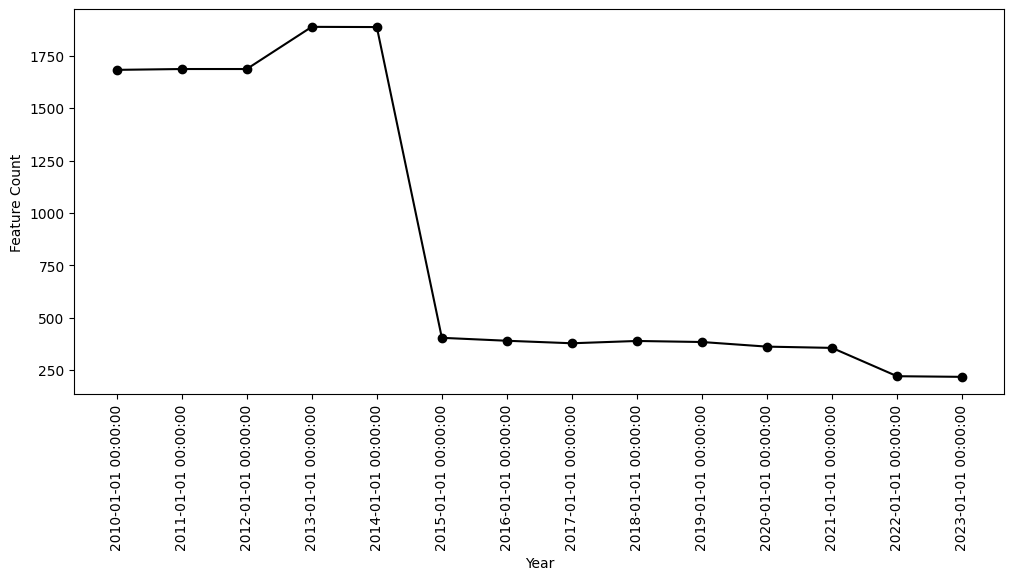

In [82]:
# Looking only at building = yes. Building = yes decreased. However, from manual exploration, it is possible to see that building = house increased. 
# This suggets that instead of a massive deletion of building data, buildings had their tagged from building = yes to building = house (or other)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Display ways only
ways = timeseries[timeseries['osm_type'] == 'way']

ax1.plot(ways['snapshot_date'], ways['count'], marker='o', color='black', label='count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Feature Count')
ax1.tick_params(axis='y')
plt.xticks(rotation=90)
plt.show()

### `get_period_representative` in practice

In [32]:
bbox_filter_all_buildings = [ # remove filter buildings=yes specifically
    "osm_type != 'relation'",
    "osm_type = 'way'",
    "(NOT map_contains(tags, 'landuse'))",
    "bbox.xmin BETWEEN 3.943491 AND 3.981857",
    "bbox.xmax BETWEEN 3.943491 AND 3.981857",
    "bbox.ymin BETWEEN 51.469764 AND 51.494673",
    "bbox.ymax BETWEEN 51.469764 AND 51.494673"
]

# Latest (most recent) version of each building in Kapelle area in 2014
start_latest, end_latest, data_latest = get_period_representative(
    osm_history_path,
    start_period='2014',
    strategy='latest',
    where_clauses=bbox_filter_all_buildings
)

# Earliest (oldest) version of each building in Kapelle area in 2014
start_earliest, end_earliest, data_earliest = get_period_representative(
    osm_history_path,
    start_period='2014',
    strategy='earliest',
    where_clauses=bbox_filter_all_buildings
)

# Longest-lived version of each building in Kapelle area in 2014
start_longest, end_longest, data_longest = get_period_representative(
    osm_history_path,
    start_period='2014',
    strategy='longest',
    where_clauses=bbox_filter_all_buildings
)

Period: 2014-01-01 00:00:00 → 2014-12-31 23:59:59 | Strategy: latest
Period: 2014-01-01 00:00:00 → 2014-12-31 23:59:59 | Strategy: earliest
Period: 2014-01-01 00:00:00 → 2014-12-31 23:59:59 | Strategy: longest


In [33]:
layer_earliest= data_earliest.select("* REPLACE(ST_GeomFromWKB(geometry) as geometry)")

layer_latest = data_latest.select("* REPLACE(ST_GeomFromWKB(geometry) as geometry)")

grid = widgets.GridBox(
    [viz(layer_earliest), viz(layer_latest)],
    layout=widgets.Layout(
        grid_template_columns="repeat(2, 600px)",
        grid_gap="10px"
    )
)

grid

/home/vbo226/.local/lib/python3.11/site-packages/lonboard/_geoarrow/ops/reproject.py:40: UserWarning: No CRS exists on data. If no data is shown on the map, double check that your CRS is WGS84.
  warn(


GridBox(children=(<lonboard._map.Map object at 0x7f48f1edd190>, <lonboard._map.Map object at 0x7f48f1ef49d0>),…

# Linking Challenges

## Define path to ohsome-planet **latest** parquet file

In [37]:
BASE_PATH = Path("/data/ohsome_planet/data/ohsome-planet") # add your own path to ohsome-planet folder
osm_latest_path = BASE_PATH / "out-netherlands" / "contributions" / "latest" / "*.parquet"

### Latest (members features only) to latest 

**Expected cardinality: 1 to many. No distinct members/refs id should fail the join**

In [38]:
# Join tag info to members of relations 

latest_distinct_members_ids = duckdb.sql(f"""
WITH unnested_members AS (
SELECT unnest(members, recursive := True)
FROM read_parquet('{osm_latest_path}') --latest file
)
SELECT DISTINCT id as osm_id, type as osm_type, ST_GeomFromWKB(geometry) as geometry --Keep distinct id, type
FROM unnested_members
""")

print(f"""Total node members: {latest_distinct_members_ids.filter("osm_type = 'node'").count('*').fetchone()[0]}""")
print(f"""Node members with NULL geometry: {latest_distinct_members_ids.filter("osm_type = 'node' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""Node members with NOT NULL geometry: {latest_distinct_members_ids.filter("osm_type = 'node' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")

print(f"""Total way members: {latest_distinct_members_ids.filter("osm_type = 'way'").count('*').fetchone()[0]}""")
print(f"""Way members with NULL geometry: {latest_distinct_members_ids.filter("osm_type = 'way' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""Way members with NOT NULL geometry: {latest_distinct_members_ids.filter("osm_type = 'way' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")


latest_to_latest = duckdb.sql(f"""
SELECT d.*, l.osm_id, l.tags  
FROM latest_distinct_members_ids d
LEFT JOIN read_parquet('{osm_latest_path}') l --latest file
USING (osm_id, osm_type)
WHERE l.osm_id IS NULL AND l.osm_type IS NULL
""")

print(f"""After join - Total node records: {latest_to_latest.filter("osm_type = 'node'").count('*').fetchone()[0]}""")
print(f"""After join - Node records with NULL geometry: {latest_to_latest.filter("osm_type = 'node' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""After join - Node records with NOT NULL geometry: {latest_to_latest.filter("osm_type = 'node' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")

print(f"""After join - Total way records: {latest_to_latest.filter("osm_type = 'way'").count('*').fetchone()[0]}""")
print(f"""After join - Way records with NULL geometry: {latest_to_latest.filter("osm_type = 'way' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""After join - Way records with NOT NULL geometry: {latest_to_latest.filter("osm_type = 'way' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total node members: 150880


RuntimeError: Query interrupted

In [74]:
# Clip to NL boundary and reperform analysis 

duckdb.sql("INSTALL httpfs; LOAD httpfs;")

netherlands = duckdb.sql("""
SELECT * 
FROM st_read('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_NLD_0.json')
""")

after_clipping_latest_distinct_members_ids = duckdb.sql(f"""
WITH unnested_members AS (
SELECT unnest(members, recursive := True)
FROM read_parquet('{osm_latest_path}') --latest file
)
SELECT DISTINCT id as osm_id, type as osm_type, role, ST_GeomFromWKB(geometry) as geometry --if role few duplicates introduced
FROM unnested_members
JOIN netherlands 
ON ST_Intersects(ST_GeomFromWKB(unnested_members.geometry), netherlands.geom) -- Important: remember to clip members, not relations
""")

print(f"""Total node members: {after_clipping_latest_distinct_members_ids.filter("osm_type = 'node'").count("*").fetchone()[0]}""")
print(f"""Node members with NULL geometry: {after_clipping_latest_distinct_members_ids.filter("osm_type = 'node' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""Node members with NOT NULL geometry: {after_clipping_latest_distinct_members_ids.filter("osm_type = 'node' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")

print(f"""Total way members: {after_clipping_latest_distinct_members_ids.filter("osm_type = 'way'").count('*').fetchone()[0]}""")
print(f"""Way members with NULL geometry: {after_clipping_latest_distinct_members_ids.filter("osm_type = 'way' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""Way members with NOT NULL geometry: {after_clipping_latest_distinct_members_ids.filter("osm_type = 'way' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")


after_clipping_latest_to_latest = duckdb.sql(f"""
SELECT d.*, l.osm_id, l.tags  
FROM after_clipping_latest_distinct_members_ids d
LEFT JOIN read_parquet('{osm_latest_path}') l --latest file
USING (osm_id, osm_type)
WHERE l.osm_id IS NULL AND l.osm_type IS NULL
""")

print(f"""After join - Total node records: {after_clipping_latest_to_latest.filter("osm_type = 'node'").count('*').fetchone()[0]}""")
print(f"""After join - Node records with NULL geometry: {after_clipping_latest_to_latest.filter("osm_type = 'node' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""After join - Node records with NOT NULL geometry: {after_clipping_latest_to_latest.filter("osm_type = 'node' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")

print(f"""After join - Total way records: {after_clipping_latest_to_latest.filter("osm_type = 'way'").count('*').fetchone()[0]}""")
print(f"""After join - Way records with NULL geometry: {after_clipping_latest_to_latest.filter("osm_type = 'way' AND geometry IS NULL").count('*').fetchone()[0]}""")
print(f"""After join - Way records with NOT NULL geometry: {after_clipping_latest_to_latest.filter("osm_type = 'way' AND geometry IS NOT NULL").count('*').fetchone()[0]}""")

Total node members: 46102
Node members with NULL geometry: 0
Node members with NOT NULL geometry: 127572
Total way members: 120123
Way members with NULL geometry: 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Way members with NOT NULL geometry: 1054068
After join - Total node records: 1765
After join - Node records with NULL geometry: 0
After join - Node records with NOT NULL geometry: 8799
After join - Total way records: 3579
After join - Way records with NULL geometry: 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

After join - Way records with NOT NULL geometry: 92632


In [75]:
viz(after_clipping_latest_to_latest)

In [76]:
duckdb.sql("""
    SELECT role, osm_type, count(*) as count
    FROM after_clipping_latest_to_latest
    GROUP BY role, osm_type
    ORDER BY count DESC
""")

┌────────────────┬──────────┬───────┐
│      role      │ osm_type │ count │
│    varchar     │ varchar  │ int64 │
├────────────────┼──────────┼───────┤
│ outer          │ way      │  2267 │
│ inner          │ way      │  1008 │
│ via            │ node     │   444 │
│ intersection   │ node     │    26 │
│ from           │ node     │    14 │
│ to             │ node     │     9 │
│ device         │ node     │     6 │
│ entrance       │ node     │     1 │
│ label          │ node     │     1 │
│ starting_point │ node     │     1 │
├────────────────┴──────────┴───────┤
│ 10 rows                 3 columns │
└───────────────────────────────────┘

In [77]:
#Now check refs (point part of ways) use area clipped to the Netherlands 
#Since refs do not have geom info, it is not possible to clip them out of Netherlands

# Join tag info to refs of ways

latest_distinct_refs_ids = duckdb.sql(f"""
WITH unnested_refs AS (
SELECT unnest(refs) as refs_id
FROM read_parquet('{osm_latest_path}') --latest file
)
SELECT DISTINCT refs_id
FROM unnested_refs
""")

print(latest_distinct_refs_ids.count('*'))

refs_latest_to_latest = duckdb.sql(f"""
SELECT d.*, l.osm_id, l.tags  
FROM latest_distinct_refs_ids d
LEFT JOIN (FROM read_parquet('{osm_latest_path}') WHERE osm_type = 'node') l --latest file
ON refs_id = l.osm_id
WHERE l.osm_id IS NULL 
""")

#Many fail the join -- understand why
print(refs_latest_to_latest.count('*'))


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│    120839667 │
└──────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│    117927485 │
└──────────────┘



### Latest to history 

**Expected cardinality: 1 to many. No distinct id should fail the join**

#### Latest ("normal" features) to history

##### `get_evolution_of_features(osm_data_latest)` function

In [78]:
# Provide choice about whether to exclude or include deleted versions?
def get_evolution_of_features(osm_data_latest):

    """
    Retrive evolution of features based on user custom input ids, type. Ensure that if members/refs ids inputted, DISTINCT ids are used for the join. 
    """

    query = f"""
    WITH features_ids AS (
    SELECT DISTINCT osm_id, osm_type  -- risk hard coding variable name here 
    FROM read_parquet('{osm_latest_path}')
    WHERE 1=1
    AND osm_version != 1 -- to make sure no features fail the join 
    )
    SELECT h.* 
    FROM features_ids
    INNER JOIN read_parquet('/local/data/vbo226/my_dataset/history/*.parquet') h 
    USING (osm_id, osm_type)
    """

    return duckdb.sql(query)

In [80]:
# Test get_evolution_of_features() on kapelle_osm_latest table

kapelle_osm_latest = duckdb.sql(f"""
SELECT * REPLACE(ST_GeomFromWKB(geometry) as geometry)
FROM read_parquet('{osm_latest_path}')
WHERE 1=1
AND bbox.xmin BETWEEN 3.943491 AND 3.981857
AND bbox.xmax BETWEEN 3.943491 AND 3.981857
AND bbox.ymin BETWEEN 51.469764 AND 51.494673
AND bbox.ymax BETWEEN 51.469764 AND 51.494673
""")

# Left join should produce 0 rows. I.e all rows were matched 
latest_to_history = duckdb.sql(f"""
    WITH features_ids AS (
    SELECT DISTINCT osm_id, osm_type  -- risk hard coding variable name here 
    FROM kapelle_osm_latest
    WHERE 1=1
    AND osm_version != 1 -- to make sure no features fail the join 
    )
    SELECT h.* 
    FROM features_ids
    LEFT JOIN read_parquet('{osm_history_path}') h 
    USING (osm_id, osm_type)
    WHERE h.osm_id IS NULL AND h.osm_type IS NULL
    """)

print(f"When join applied to local area (Kapelle), it performs as expected")

latest_to_history.count('*')

When join applied to local area (Kapelle), it performs as expected


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│            0 │
└──────────────┘

In [81]:
# # Test if function fails for the entire NL (is it just a matter of remove v1?). Single distinct id from latest matched to 1 or more OSM history versions. 
# 32 fail to match. Quite old features (all nodes, osm_minor_version = 0, contribution_type = CREATION BUT osm_version != 1. Inconsistency. It is not what expected)
# Those features turns out have been redacted. How to deal with those? How to deal with mismatch between CREATION and osm_version != 1?
# Not all explained (e.g UK)
test = duckdb.sql(f"""
    WITH features_ids AS (
    SELECT DISTINCT osm_id, osm_type, osm_version, osm_minor_version, contrib_type, ST_GeomFromWKB(geometry) as geometry
    FROM read_parquet('{osm_latest_path}') -- all netherlands (no clipping) 
    WHERE osm_version != 1
    )
    SELECT f.* 
    FROM features_ids f
    LEFT JOIN read_parquet('{osm_history_path}') h 
    USING (osm_id, osm_type)
    WHERE h.osm_id IS NULL and h.osm_type IS NULL
    """
          )

test.show(max_width=100)


viz(test)

# Is there a way to know how many features have been redacted in OSM? Double check that those are all within the Netherlands

┌───────────┬──────────┬─────────────┬───────────────────┬──────────────┬──────────────────────────┐
│  osm_id   │ osm_type │ osm_version │ osm_minor_version │ contrib_type │         geometry         │
│   int64   │ varchar  │    int32    │       int32       │   varchar    │         geometry         │
├───────────┼──────────┼─────────────┼───────────────────┼──────────────┼──────────────────────────┤
│  34206580 │ node     │           7 │                 0 │ CREATION     │ POINT (4.9506469 52.31…  │
│  34044136 │ node     │           5 │                 0 │ CREATION     │ POINT (6.0139275 50.86…  │
│  34047706 │ node     │           5 │                 0 │ CREATION     │ POINT (4.4848024 52.17…  │
│ 777473622 │ node     │           4 │                 0 │ CREATION     │ POINT (4.531008 52.372…  │
│ 567997223 │ node     │           5 │                 0 │ CREATION     │ POINT (4.3209953 52.06…  │
│  21310035 │ node     │           2 │                 0 │ CREATION     │ POINT (-1.5874897

#### Latest (members) to history